## Environment setup

### Check GPU availability

Let's make sure that we have access to GPU. We can use `nvidia-smi` command to do that.

In [1]:
!nvidia-smi

### Install dependencies

Installs RF-DETR version 1.2.1 or higher (which includes the new Nano, Small, and Medium checkpoints), along with Supervision for benchmarking and Roboflow for pulling datasets and uploading models to the Roboflow platform.

In [2]:
!pip install -q rfdetr==1.2.1 supervision==0.26.1 roboflow

In [3]:
import os
from zipfile import ZipFile

In [2]:
path = os.getcwd()
print(path)

d:\Studium\5. Semester\PA2\Glass-Defect-Detection-Evaluating-Object-Detection-Models\Coding\Model_Code\RF-DETR


In [ ]:
# Create the directory if it doesn't exist
extract_dir = "data"
os.makedirs(extract_dir, exist_ok=True)

with ZipFile("kaggle_glass_defect_COCO.zip", "r") as data_set:
    data_set.extractall(extract_dir)

In [17]:
DATA_YAML = "data/config.yaml"
data_set_dir = "../../Datasets/Dataset_kaggle_glass/kaggle_glass_defect_COCO"

## Train RF-DETR on custom dataset

### Choose the right `batch_size`

Different GPUs have different amounts of VRAM (video memory), which limits how much data they can handle at once during training. To make training work well on any machine, you can adjust two settings: `batch_size` and `grad_accum_steps`. These control how many samples are processed at a time. The key is to keep their product equal to 16 — that’s our recommended total batch size. For example, on powerful GPUs like the A100, set `batch_size=16` and `grad_accum_steps=1`. On smaller GPUs like the T4, use `batch_size=4` and `grad_accum_steps=4`. We use a method called gradient accumulation, which lets the model simulate training with a larger batch size by gradually collecting updates before adjusting the weights.

In [8]:
from rfdetr import RFDETRNano

model = RFDETRNano()

Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
Using patch size 16 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
Loading pretrain weights


In [ ]:
model.train(dataset_dir=data_set_dir, epochs=100, batch_size=8, grad_accum_steps=2)

In [ ]:
!zip -r /content/kaggle_coco_results_1.zip /content/output

In [ ]:
from PIL import Image

Image.open("/content/output/metrics_plot.png")

## Evaluate Fine-tuned RF-DETR Model

Before benchmarking the model, we need to load the best saved checkpoint. To ensure it fits on the GPU, we first need to free up GPU memory. This involves deleting any remaining references to previously used objects, triggering Python’s garbage collector, and clearing the CUDA memory cache.

In [6]:
import gc
import torch
import weakref

def cleanup_gpu_memory(obj=None, verbose: bool = False):

    if not torch.cuda.is_available():
        if verbose:
            print("[INFO] CUDA is not available. No GPU cleanup needed.")
        return

    def get_memory_stats():
        allocated = torch.cuda.memory_allocated()
        reserved = torch.cuda.memory_reserved()
        return allocated, reserved

    torch.cuda.synchronize()

    if verbose:
        alloc, reserv = get_memory_stats()
        print(f"[Before] Allocated: {alloc / 1024**2:.2f} MB | Reserved: {reserv / 1024**2:.2f} MB")

    # Ensure we drop all strong references
    if obj is not None:
        ref = weakref.ref(obj)
        del obj
        if ref() is not None and verbose:
            print("[WARNING] Object not fully garbage collected yet.")

    gc.collect()
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()

    torch.cuda.synchronize()

    if verbose:
        alloc, reserv = get_memory_stats()
        print(f"[After]  Allocated: {alloc / 1024**2:.2f} MB | Reserved: {reserv / 1024**2:.2f} MB")

In [7]:
cleanup_gpu_memory(model, verbose=True)

We load the best-performing model from the `checkpoint_best_total.pth` file using the `RFDETRNano` class. This checkpoint contains the trained weights from our most successful training run. After loading, we call `optimize_for_inference()`, which prepares the model for efficient inference.

In [9]:
model = RFDETRNano(pretrain_weights="checkpoint_best_total.pth")
model.optimize_for_inference()

Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
Using patch size 16 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.


num_classes mismatch: pretrain weights has 1 classes, but your model has 90 classes
reinitializing detection head with 1 classes


Loading pretrain weights


`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


In [20]:
import supervision as sv

ds = sv.DetectionDataset.from_coco(
    images_directory_path=f"{data_set_dir}/test",
    annotations_path=f"{data_set_dir}/test/_annotations.coco.json",
)

In [11]:
import supervision as sv
from tqdm import tqdm
from supervision.metrics import MeanAveragePrecision
from PIL import Image
targets = []
predictions = []

for path, image, annotations in tqdm(ds):
    image = Image.open(path)
    detections = model.predict(image, threshold=0)

    targets.append(annotations)
    predictions.append(detections)

100%|██████████| 21/21 [00:11<00:00,  1.85it/s]


In [37]:
map_metric = MeanAveragePrecision()
map_result = map_metric.update(predictions, targets).compute()
print(map_result)

In [78]:
from supervision.metrics import F1Score, Precision, Recall

f1 = F1Score()
prec = Precision()
rec = Recall()

f1 = f1.update(predictions, targets).compute()
prec = prec.update(predictions, targets).compute()
rec = rec.update(predictions, targets).compute()

f1.plot()
prec.plot()
rec.plot()


In [1]:
from supervision.metrics import F1Score, Precision, Recall
import matplotlib.pyplot as plt
import numpy as np

# # ... (Ihre predictions und targets Logik) ...

# f1_obj = F1Score()
# prec_obj = Precision()
# rec_obj = Recall()

# # Update und Compute
# f1_result = f1_obj.update(predictions, targets).compute()
# prec_result = prec_obj.update(predictions, targets).compute()
# rec_result = rec_obj.update(predictions, targets).compute()

# === WICHTIGER TEIL: Extrahieren der Daten aus dem F1Score-Objekt ===
# Die genaue Struktur kann je nach supervision-Version variieren, 
# aber oft werden die Daten für die Balken als ein Array von Werten gespeichert.

# Angenommen, das F1Score-Objekt enthält eine Liste der berechneten Werte:
# Wir verwenden hier die Achsen-Namen aus dem von Ihnen gezeigten Bild.
# labels = ['Recall@50', 'Recall@75', 'Small: R@50', 'Small: R@75', 'Medium: R@50', 'Medium: R@75', 'Large: R@50', 'Large: R@75']
# values = f1_obj.result # Oder ein ähnliches Attribut, das die Werte enthält.
# Wenn das result-Objekt eine komplexere Struktur ist, müssten Sie die Werte filtern.

# Für das Rec.plot() von Ihrem Bild:
rec_labels = ['Recall@50', 'Recall@75', 'Small: R@50', 'Small: R@75', 'Medium: R@50', 'Medium: R@75', 'Large: R@50', 'Large: R@75']
rec_values = np.array([1.00, 0.96, 1.00, 0.75, 1.00, 1.00, 1.00, 1.00]) # Ihre echten Rec.plot() Werte

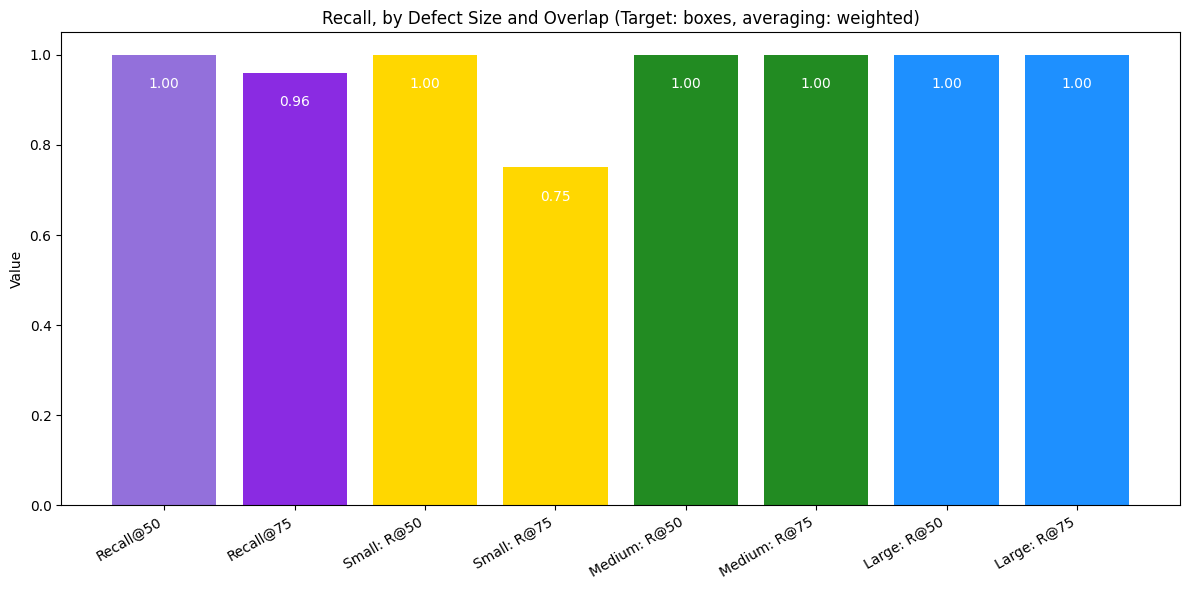

Das benutzerdefinierte Balkendiagramm mit Labels im Balken wurde gespeichert.


In [4]:
# === Plotten des Recalls (wie in Ihrem Bild) mit benutzerdefinierter Text-Platzierung ===

plt.figure(figsize=(12, 6))
bars = plt.bar(rec_labels, rec_values, color=['mediumpurple', 'blueviolet', 'gold', 'gold', 'forestgreen', 'forestgreen', 'dodgerblue', 'dodgerblue'])

# Passen Sie die X-Achsen-Beschriftungen an (wie im Originalbild)
plt.xticks(rotation=30, ha='right') 

plt.title('Recall, by Defect Size and Overlap (Target: boxes, averaging: weighted)')
plt.ylabel('Value')
plt.ylim(0, 1.05) # Stellt sicher, dass alle Balken vollständig sichtbar sind

# Hinzufügen der Labels: Jetzt mit angepasster Y-Position (innerhalb des Balkens)
for bar in bars:
    yval = bar.get_height()
    
    # Platzierung: Y-Koordinate ist knapp unterhalb der Oberkante des Balkens (z.B. yval - 0.05)
    # va='top' stellt sicher, dass die Oberkante des Textes dort beginnt.
    plt.text(
        bar.get_x() + bar.get_width()/2, # X-Position (Mitte des Balkens)
        yval - 0.05,                     # Y-Position (5% unterhalb der Spitze)
        f"{yval:.2f}",                   # Formatierter Wert (zwei Dezimalstellen)
        ha='center',                     # Horizontal zentriert
        va='top',                        # Vertikal: Text endet an dieser Y-Position
        fontsize=10,
        color='white'                    # Weiße Schrift für bessere Sichtbarkeit in farbigen Balken
    )

plt.tight_layout() # Stellt sicher, dass die Labels nicht abgeschnitten werden
plt.savefig('custom_recall_plot.png')
plt.show()

print("Das benutzerdefinierte Balkendiagramm mit Labels im Balken wurde gespeichert.")

In [82]:
map_result.plot()

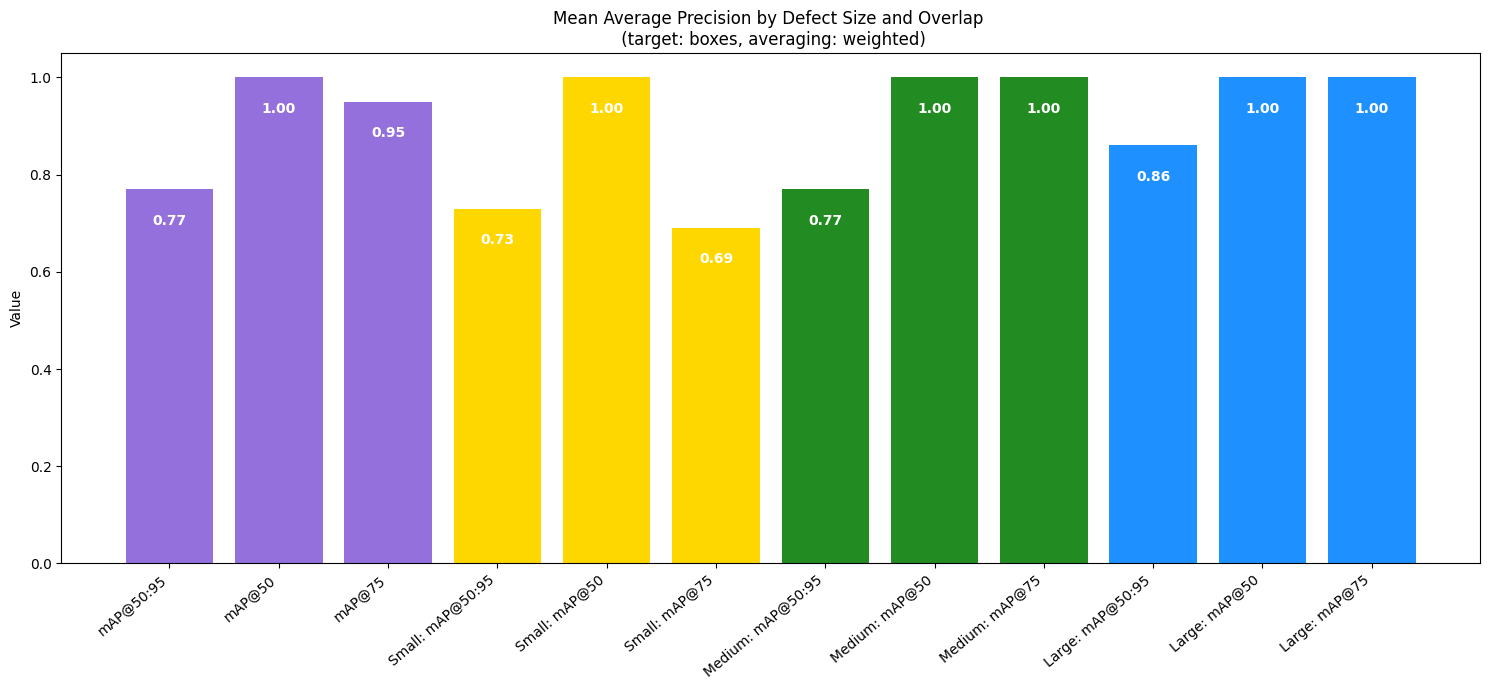

Das mAP-Balkendiagramm mit Labels im Balken wurde als 'custom_map_plot.png' gespeichert.


In [5]:

# 1. Daten extrahieren (Werte direkt aus Ihrem Bild übernommen)
# X-Achsen-Labels:
labels = [
    'mAP@50:95', 'mAP@50', 'mAP@75',  # Gesamtmetriken (Lila)
    'Small: mAP@50:95', 'Small: mAP@50', 'Small: mAP@75', # Small (Gelb)
    'Medium: mAP@50:95', 'Medium: mAP@50', 'Medium: mAP@75', # Medium (Grün)
    'Large: mAP@50:95', 'Large: mAP@50', 'Large: mAP@75'   # Large (Blau)
]

# Y-Achsen-Werte (direkt aus den Beschriftungen des Bildes):
values = np.array([
    0.77, 1.00, 0.95,
    0.73, 1.00, 0.69,
    0.77, 1.00, 1.00,
    0.86, 1.00, 1.00
])

# 2. Farben definieren (Basierend auf dem Schema in Ihrem Bild)
# 3 lila, 3 gelb, 3 grün, 3 blau
colors = (
    ['mediumpurple'] * 3 + 
    ['gold'] * 3 + 
    ['forestgreen'] * 3 + 
    ['dodgerblue'] * 3
)

# 3. Plot erstellen
plt.figure(figsize=(15, 7))
# Erstellung des Balkendiagramms
bars = plt.bar(labels, values, color=colors) 

# Titel und Achsen
plt.title('Mean Average Precision by Defect Size and Overlap \n (target: boxes, averaging: weighted)')
plt.ylabel('Value')
plt.ylim(0, 1.05) # Stellt sicher, dass die Skala bis 1.0 geht und Platz für den Titel ist
plt.xticks(rotation=40, ha='right') # Dreht die Labels, damit sie sich nicht überlappen

# 4. Hinzufügen der Labels IN die Balken (Anpassung der Y-Position)
for bar in bars:
    yval = bar.get_height()
    
    # Platzierung: Y-Koordinate ist knapp unterhalb der Oberkante des Balkens (z.B. yval - 0.05)
    # va='top' stellt sicher, dass die Oberkante des Textes dort beginnt.
    # Setzen Sie die Farbe auf Weiß oder Schwarz, um die Lesbarkeit zu gewährleisten.
    text_color = 'white' if yval > 0.3 else 'black' # Wechselt die Textfarbe basierend auf der Balkenhöhe
    
    plt.text(
        bar.get_x() + bar.get_width()/2, # X-Position (Mitte des Balkens)
        yval - 0.05,                     # Y-Position (5% unterhalb der Spitze)
        f"{yval:.2f}",                   # Formatierter Wert (zwei Dezimalstellen)
        ha='center',                     # Horizontal zentriert
        va='top',                        # Vertikal: Text endet an dieser Y-Position
        fontsize=10,
        color=text_color,
        fontweight='bold'
    )

plt.tight_layout() # Optimiert das Layout
plt.savefig('custom_map_plot.png')
plt.show()
plt.close()

print("Das mAP-Balkendiagramm mit Labels im Balken wurde als 'custom_map_plot.png' gespeichert.")

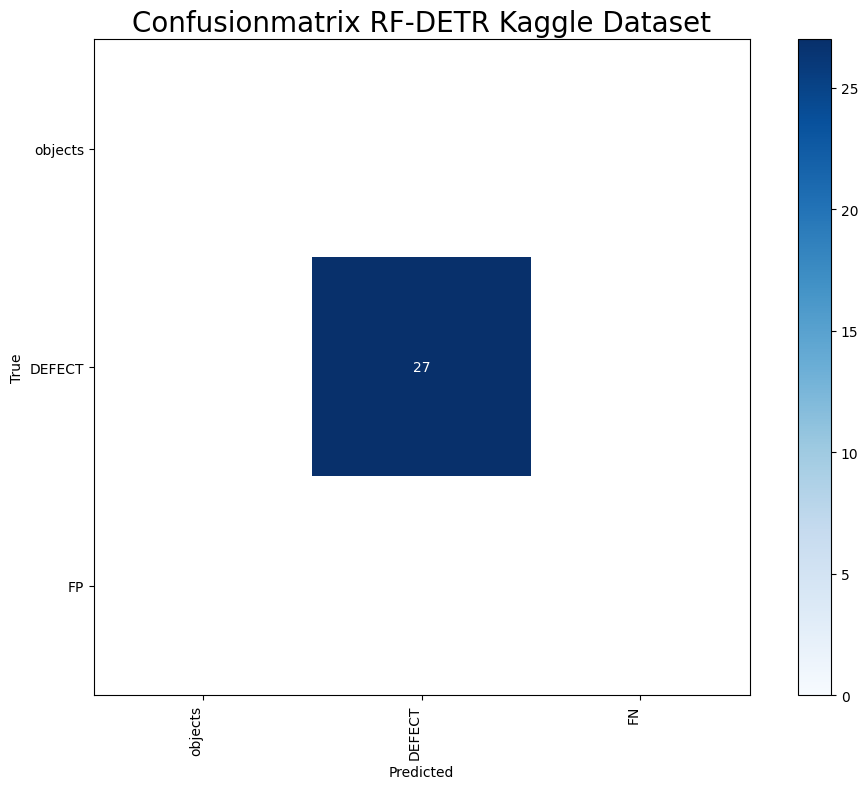

Die Konfusionsmatrix wurde unter 'confusion_matrix_test_run.png' gespeichert.


In [47]:
import supervision as sv
# from supervision.metrics import ConfusionMatrix
import matplotlib.pyplot as plt

# 1. Konfusionsmatrix initialisieren und berechnen
# Die Anzahl der Klassen ist die Anzahl der erkannten Klassen plus eine für den Hintergrund ("background").
num_classes = len(ds.classes) + 1
class_names = ds.classes

cm_metric = sv.ConfusionMatrix.from_detections(
    predictions=predictions,
    targets=targets,
    classes=class_names
)

# 2. Plot erstellen und speichern
plot = cm_metric.plot(title="Confusionmatrix RF-DETR Kaggle Dataset", fig_size=(10,8))
plt.savefig("confusion_matrix_test_run.png")
plt.show()
plt.close()

print("Die Konfusionsmatrix wurde unter 'confusion_matrix_test_run.png' gespeichert.")

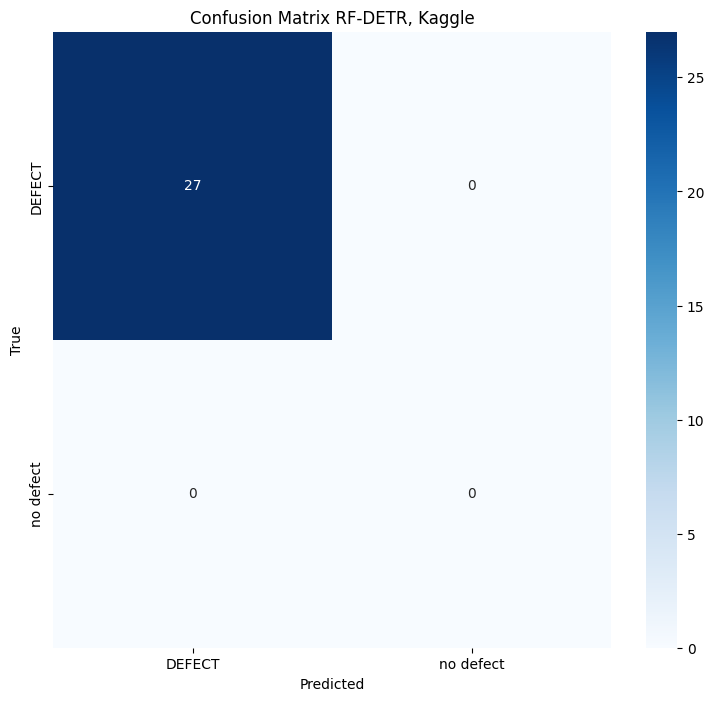


Consolidated 2x2 Matrix (True Row vs. Predicted Column):

           DEFECT  no defect
DEFECT         27          0
no defect       0          0


In [5]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# --- 1. Construct the 2x2 Matrix Data ---
# Classes: 0=defect, 1=glass, 2=Background

# Row 0 (True: defect)
# P: defect (141), P: glass (1), P: Background (FN = 55)
row_defect = [27, 0] 

# Row 1 (True: glass)
# P: defect (50), P: glass (173), P: Background (FN for glass, assumed 0)
row_glass = [0, 0] 


cm_2x2_data = np.array([
    row_defect, 
    row_glass, 
])

labels_2x2 = ['DEFECT', 'no defect']


# --- 2. Plot the 2x2 Matrix ---
plt.figure(figsize=(9, 8))
sns.heatmap(
    cm_2x2_data, 
    annot=True, 
    fmt='d', 
    cmap='Blues', 
    cbar=True,
    xticklabels=labels_2x2,
    yticklabels=labels_2x2
)

plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix RF-DETR, Kaggle')
plt.show()

# Print the matrix for easy reference
print("\nConsolidated 2x2 Matrix (True Row vs. Predicted Column):\n")
df = pd.DataFrame(cm_2x2_data, index=labels_2x2, columns=labels_2x2)
print(df)